<a href="https://colab.research.google.com/github/johnsteeleprogramming/techconsulting/blob/DS_Assignment4/Assignment_4_Predict_Movie_Success_with_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ASSIGNMENT 4 - PREDICTING MOVIE SUCCESS WITH ARTIFICIAL NEURAL NETWORKS

## IMPORT LIBRARIES

In [280]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## READ IN TRAINING DATA

### UPLOAD TRAINING DATA

In [281]:
training_data = '/content/train_movie.csv'
testing_data = '/content/test_movie.csv'
testing_data_answers = '/content/test_movie_answers.csv'
headers = pd.read_csv(training_data, nrows=0)
print(headers.columns.tolist())
X_columns_to_read_train = ['TimeOfYear', 'Audience', 'DaysInTheatre', 'MovieType', 'YearsAgoReleased', 'AdvertisingBudget', 'MovieRating']
X_movie_train = pd.read_csv(training_data, usecols=X_columns_to_read_train)
print(X_movie_train)
y_columns_to_read_train = ['Profitable']
y_movie_train = pd.read_csv(training_data, usecols=y_columns_to_read_train)
print(y_movie_train)

['MovieId', 'Profitable', 'TimeOfYear', 'NameOfMovie', 'Audience', 'DaysInTheatre', 'MovieType', 'YearsAgoReleased', 'ProductionCompany', 'AdvertisingBudget', 'AdvertisingCompany', 'MovieRating']
     TimeOfYear Audience  DaysInTheatre  MovieType  YearsAgoReleased  \
0             3     male           22.0          1                 0   
1             1   female           38.0          1                 0   
2             3   female           26.0          0                 0   
3             1   female           35.0          1                 0   
4             3     male           35.0          0                 0   
..          ...      ...            ...        ...               ...   
886           2     male           27.0          0                 0   
887           1   female           19.0          0                 0   
888           3   female            NaN          1                 2   
889           1     male           26.0          0                 0   
890         

### CONVERT TRAINING DATA TO NUMPY MATRICES

In [282]:
X_movie_train = X_movie_train.to_numpy()
y_movie_train = y_movie_train.to_numpy()

### EXPLORATORY DATA ANALYSIS

#### METHOD TO PERFORM EDA ON TRAINING DATA

In [283]:
def cleanMovieData(X):

  N = len(X)
  for i in range(N):
    if X[i, 1] == 'male':
      X[i, 1] = 1
    else:
      X[i, 1] = 0

  averageAge = 0
  ageNotNanCount = 0
  for i in range(N):
    if not np.isnan(X[i, 2]):
      averageAge += X[i, 2]
      ageNotNanCount += 1
  averageAge /= ageNotNanCount
  averageAge = round(averageAge, 1)

  for i in range(N):
    if np.isnan(X[i, 2]):
      X[i, 2] = averageAge

  for i in range(N):
    if X[i, 6] == 'S':
      X[i, 6] = 0
    elif X[i, 6] == 'C':
      X[i, 6] = 1
    else:
      X[i, 6] = 2

#### CLEAN THE TRAINING DATA

In [284]:
print(X_movie_train)
cleanMovieData(X_movie_train)
print(X_movie_train)

[[3 'male' 22.0 ... 0 7.25 'S']
 [1 'female' 38.0 ... 0 71.2833 'C']
 [3 'female' 26.0 ... 0 7.925 'S']
 ...
 [3 'female' nan ... 2 23.45 'S']
 [1 'male' 26.0 ... 0 30.0 'C']
 [3 'male' 32.0 ... 0 7.75 'Q']]
[[3 1 22.0 ... 0 7.25 0]
 [1 0 38.0 ... 0 71.2833 1]
 [3 0 26.0 ... 0 7.925 0]
 ...
 [3 0 29.7 ... 2 23.45 0]
 [1 1 26.0 ... 0 30.0 1]
 [3 1 32.0 ... 0 7.75 2]]


## ARTIFICIAL NEURAL NETWORKS

### SHALLOW ANN

#### USEFUL FUNCTIONS FOR SHALLOW ANN

In [285]:
def one_hot_encode(y):
  N = len(y)
  K = len(set(y))
  Y = np.zeros((N,K))
  for i in range(N):
    Y[i,y[i]] = 1
  return Y

def accuracy(y, y_hat):
  return np.mean(y==y_hat)

def cross_entropy_shallow(Y, P_hat):
  return -np.sum(Y*np.log(P_hat))

#### ACTIVATION FUNCTIONS FOR SHALLOW ANN

In [286]:
def linear(H):
  return H

def Sigmoid(H):
  return 1/(1+np.exp(-H))

def ReLU(H):
  return H*(H>0)

def softmax(H):
  eH = np.exp(H)
  return eH/eH.sum(axis=1, keepdims=True)

#### SHALLOW ANN CLASSIFIER

In [287]:
class Shallow_ANN():

  def fit(self, X, y, activation=None, neurons=6, eta=1e-3, epochs=1e3, show_curve=True, title='LINEAR'):
    epochs = int(epochs)
    N, D = X.shape
    Y = one_hot_encode(y)
    K = Y.shape[1]

    self.W = {l: np.random.randn(M[0],M[1]) for l, M in enumerate(zip([D,neurons],[neurons,K]), 1)}
    self.B = {l: np.random.randn(M) for l, M in enumerate([neurons, K], 1)}

    if activation==None:
      self.a = {1:np.tanh, 2:linear}
    else:
      self.a = {1:np.tanh, 2:activation}

    J = np.zeros(epochs)

    for epoch in range(epochs):
      self.__forward__(X)
      J[epoch] = cross_entropy_shallow(Y, self.Z[2])

      self.W[2] -= eta*(1/N)*self.Z[1].T@(self.Z[2]-Y)
      self.B[2] -= eta*(1/N)*(self.Z[2]-Y).sum(axis=0)

      self.W[1] -= eta*(1/N)*X.T@((self.Z[2]-Y)@self.W[2].T*(1-self.Z[1]**2))
      self.B[1] -= eta*(1/N)*((self.Z[2]-Y)@self.W[2].T*(1-self.Z[1]**2)).sum(axis=0)

    if show_curve:
      plt.figure()
      plt.plot(J)
      plt.xlabel('epochs')
      plt.ylabel('$\mathcal{J}$')
      plt.title('Training Curve - Shallow ANN' + ' - ' + title)

  def __forward__(self, X):
    self.Z = {0:X}
    for l in sorted(self.W.keys()):
      self.Z[l] = self.a[l](self.Z[l-1]@self.W[l]+self.B[l])

  def predict(self, X):
    return self.Z[2].argmax(axis=1)

#### IMPLEMENTATION OF SHALLOW ANN CLASSIFIER

In [288]:
def main():

  X = X_movie_train.astype(float)
  y = np.hstack(y_movie_train)

  neurons=3
  eta=1e-2
  epochs=1e4
  printWeightsAndBiases = False

  print('--- LINEAR ---')
  activation=linear

  my_ann = Shallow_ANN()
  my_ann.fit(X, y, activation, neurons, eta, epochs, show_curve=True, title='LINEAR')
  y_hat_movie_train =my_ann.predict(X)

  if printWeightsAndBiases:
    print(my_ann.W)
    print(my_ann.B)

  print("Accuracy - linear: ", accuracy(y, y_hat_movie_train))

  print('--- Sigmoid ---')
  activation=Sigmoid

  my_ann = Shallow_ANN()
  my_ann.fit(X, y, activation, neurons, eta, epochs, show_curve=True, title='SIGMOID')
  y_hat_movie_train =my_ann.predict(X)


  if printWeightsAndBiases:
    print(my_ann.W)
    print(my_ann.B)

  print("Accuracy - Sigmoid: ", accuracy(y, y_hat_movie_train))

  print('--- ReLU ---')
  activation=ReLU

  my_ann = Shallow_ANN()
  my_ann.fit(X, y, activation, neurons, eta, epochs, show_curve=True, title='ReLU')
  y_hat_movie_train =my_ann.predict(X)

  if printWeightsAndBiases:
    print(my_ann.W)
    print(my_ann.B)

  print("Accuracy - ReLU: ", accuracy(y, y_hat_movie_train))

  print('--- softmax ---')
  activation=softmax

  my_ann = Shallow_ANN()
  my_ann.fit(X, y, activation, neurons, eta, epochs, show_curve=True, title='SOFTMAX')
  y_hat_movie_train =my_ann.predict(X)

  if printWeightsAndBiases:
    print(my_ann.W)
    print(my_ann.B)

  print("Accuracy - softmax: ", accuracy(y, y_hat_movie_train))

#### RUNNING SHALLOW ANN CLASSIFIER

--- LINEAR ---


<ipython-input-285-c757df1e02ac>:13: RuntimeWarning: invalid value encountered in log
  return -np.sum(Y*np.log(P_hat))


Accuracy - linear:  0.6790123456790124
--- Sigmoid ---
Accuracy - Sigmoid:  0.6790123456790124
--- ReLU ---


<ipython-input-285-c757df1e02ac>:13: RuntimeWarning: divide by zero encountered in log
  return -np.sum(Y*np.log(P_hat))
<ipython-input-285-c757df1e02ac>:13: RuntimeWarning: invalid value encountered in multiply
  return -np.sum(Y*np.log(P_hat))


Accuracy - ReLU:  0.6823793490460157
--- softmax ---
Accuracy - softmax:  0.6902356902356902


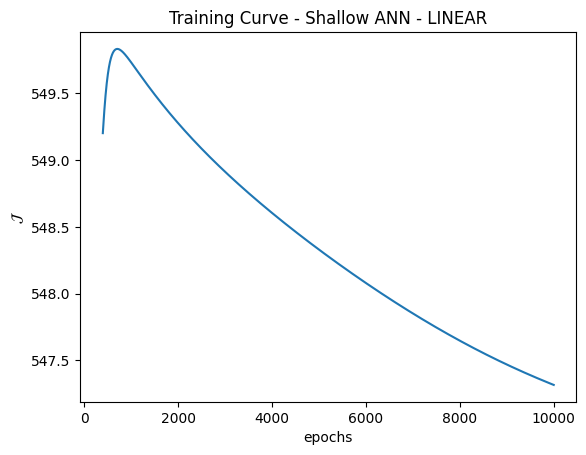

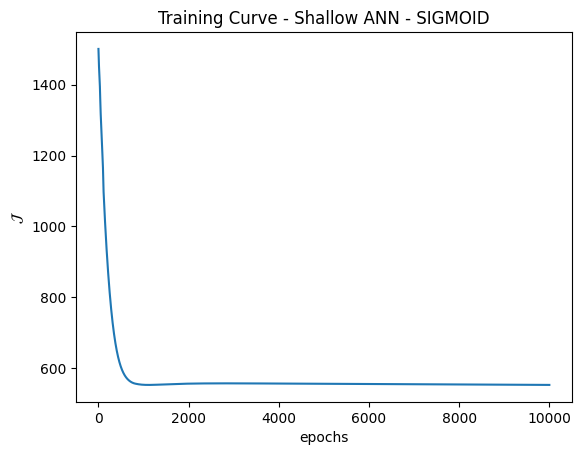

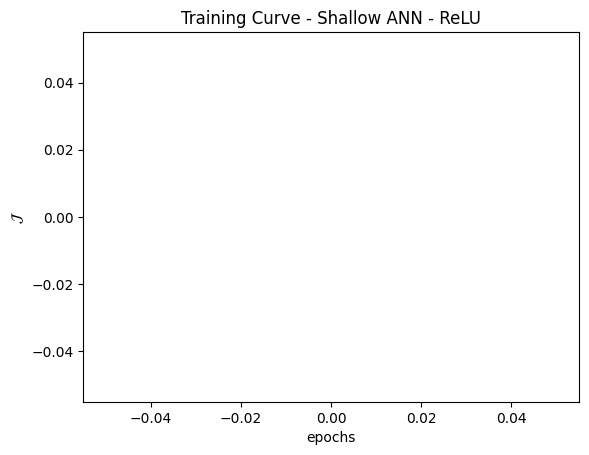

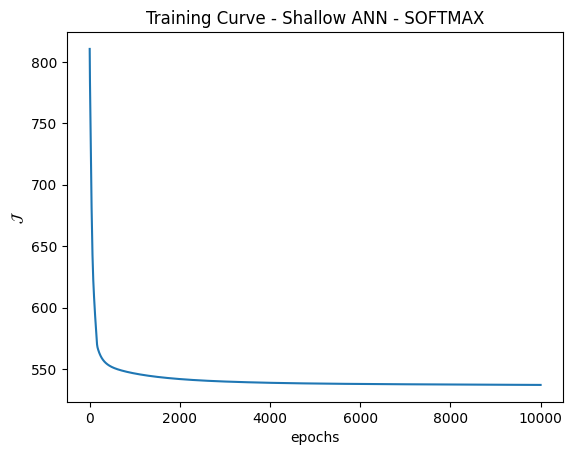

In [289]:
if __name__=='__main__':
  main()

### ARTIFICIAL NEURAL NETWORK WITH VARIABLE ARCHITECTURE AND BACK PROPAGATION

#### ACTIVATION FUNCTIONS

In [290]:
def linear(H):
  return H

def ReLU(H):
  return H*(H>0)

def sigmoid(H):
  return 1/(1+np.exp(-H))

def softmax(H):
  eH=np.exp(H)
  return eH/eH.sum(axis=1, keepdims=True)

#### HELPFUL FUNCTIONS

In [291]:
def cross_entropy_ann(Y, P_hat):
  return -(1/len(Y))*np.sum(Y*np.log(P_hat))

def OLS(Y, Y_hat):
  return (1/(2*len(Y)))*np.sum((Y-Y_hat)**2)

def one_hot(y):
  N=len(y)
  K=len(set(y))
  Y = np.zeros((N,K))
  for i in range(N):
    Y[i,y[i]]=1
  return Y

def accuracy(y, y_hat):
  return np.mean(y==y_hat)

def R2(y, y_hat):
  return 1-np.sum((y-y_hat)**2)/np.sum((y - y.mean())**2)

#### DERIVATIVES OF ACTIVATION FUNCTIONS

In [292]:
def derivative(Z, a):
  if a==linear:
    return 1
  elif a==sigmoid:
    return Z*(1-Z)
  elif a==np.tanh:
    return 1-Z*Z
  elif a==ReLU:
    return (Z>0).astype(int)
  else:
    ValueError('UnknownActivation')

#### ANN CLASS

In [293]:
class ANN():
  def __init__(self, architecture, activations=None, mode=0):
    self.mode = mode
    self.architecture = architecture
    self.activations = activations
    self.L = len(architecture)+1

  def fit(self, X, y, eta=1e-2, epochs=1e3, show_curve=True, title='LINEAR'):
    epochs = int(epochs)
    if self.mode:
      Y = y
      K = 1
    else:
      Y = one_hot(y)
      K = Y.shape[1]

    N, D = X.shape

    self.W = {l: np.random.randn(M[0],M[1]) for l, M in enumerate(zip(([D]+self.architecture), (self.architecture +[K])),1)}
    self.B = {l: np.random.randn(M) for l, M in enumerate(self.architecture+[K],1)}

    if self.activations is None:
      self.a = {l: ReLU for l in range(1, self.L)}
    else:
      self.a = {l: act for l, act in enumerate(self.activations, 1)}

    if self.mode:
      self.a[self.L] = linear
    else:
      self.a[self.L] = softmax

    J = np.zeros(epochs)

    for epoch in range(epochs):
      self.__forward__(X)
      if self.mode:
        J[epoch] = OLS(Y, self.Z[self.L])
      else:
        J[epoch] = cross_entropy_ann(Y, self.Z[self.L])

      dH = (1/N)*(self.Z[self.L]-Y)

      for l in sorted(self.W.keys(), reverse=True):
        dW = self.Z[l-1].T@dH
        dB = dH.sum(axis=0)

        self.W[l] -= eta*dW
        self.B[l] -= eta*dB

        if l > 1:
          dZ = dH@self.W[l].T
          dH = dZ*derivative(self.Z[l-1], self.a[l-1])

    if show_curve:
      plt.figure()
      plt.plot(J)
      plt.xlabel('epochs')
      plt.ylabel('$\mathcal{J}$')
      plt.title('Training Curve - ANN - ' + title)

  def __forward__(self, X):
    self.Z = {0:X}
    for l in sorted(self.W.keys()):
      self.Z[l] = self.a[l](self.Z[l-1]@self.W[l] + self.B[l])

  def predict(self, X):
    self.__forward__(X)
    if self.mode:
      return self.Z[self.L]
    else:
      return self.Z[self.L].argmax(axis=1)

#### IMPLEMENTATION OF ANN CLASSIFICATION

In [294]:
def main_class():

  X = X_movie_train.astype(float)
  y = np.hstack(y_movie_train)

  architecture=[10,6]
  eta=1e-2
  epochs=1e4
  printWeightsAndBiases = False

  print('--- LINEAR ---')
  my_ann_classifier = ANN(architecture, activations=[np.tanh,linear])
  my_ann_classifier.fit(X, y, eta, epochs, title='LINEAR')
  y_hat = my_ann_classifier.predict(X)

  if printWeightsAndBiases:
    print(my_ann_classifier.W)
    print(my_ann_classifier.B)

  print(f'Training Accuracy - LINEAR: {accuracy(y,y_hat):0.4f}')

  print('--- SIGMOID ---')
  my_ann_classifier = ANN(architecture, activations=[np.tanh,sigmoid])
  my_ann_classifier.fit(X, y, eta, epochs, title='SIGMOID')
  y_hat = my_ann_classifier.predict(X)

  if printWeightsAndBiases:
    print(my_ann_classifier.W)
    print(my_ann_classifier.B)

  print(f'Training Accuracy - SIGMOID: {accuracy(y,y_hat):0.4f}')

  print('--- ReLU ---')
  my_ann_classifier = ANN(architecture=[10,6], activations=[np.tanh,ReLU])
  my_ann_classifier.fit(X, y, eta, epochs, title='ReLU')
  y_hat = my_ann_classifier.predict(X)

  if printWeightsAndBiases:
    print(my_ann_classifier.W)
    print(my_ann_classifier.B)

  print(f'Training Accuracy - ReLU: {accuracy(y,y_hat):0.4f}')

--- LINEAR ---
Training Accuracy - LINEAR: 0.7912
--- SIGMOID ---
Training Accuracy - SIGMOID: 0.7037
--- ReLU ---
Training Accuracy - ReLU: 0.6902


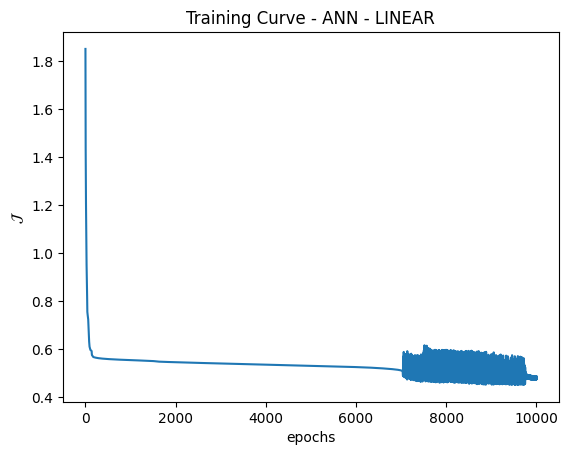

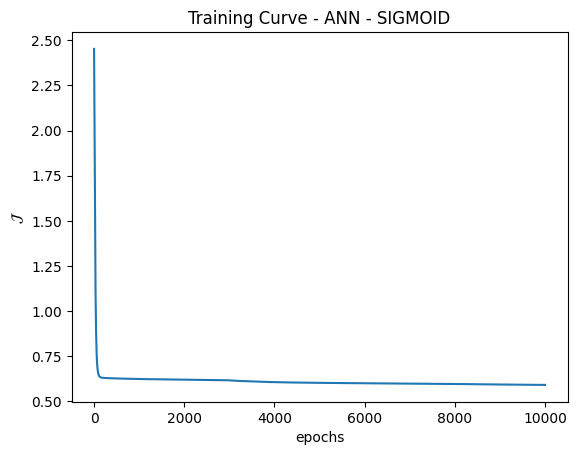

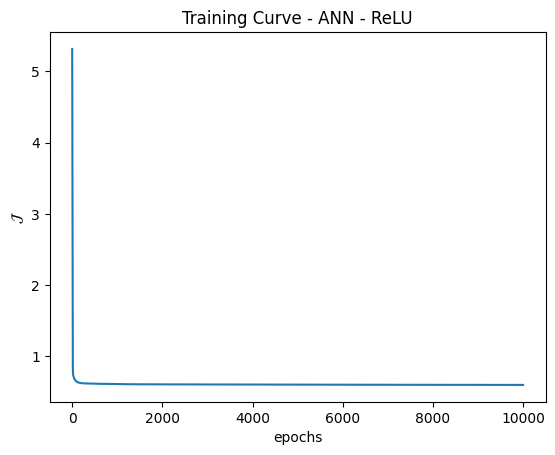

In [295]:
if __name__=='__main__':
  main_class()